# Heart Disease Patient Outcome Prediction

**Objective:** Build and compare classification models that predict whether a patient shows evidence of heart disease using the UCI Cleveland dataset.

This notebook covers data loading, quality checks, cleaning, exploratory analysis, preprocessing, model comparison, threshold analysis, interpretation, and model export.

Import Library

In [21]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df=pd.read_csv("heart_disease_cleveland.csv")
df

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,major_vessels,thalassemia,diagnosis
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


Data Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    float64
 1   sex                  303 non-null    float64
 2   chest_pain_type      303 non-null    float64
 3   resting_bp           303 non-null    float64
 4   cholesterol          303 non-null    float64
 5   fasting_blood_sugar  303 non-null    float64
 6   resting_ecg          303 non-null    float64
 7   max_heart_rate       303 non-null    float64
 8   exercise_angina      303 non-null    float64
 9   st_depression        303 non-null    float64
 10  st_slope             303 non-null    float64
 11  major_vessels        299 non-null    float64
 12  thalassemia          301 non-null    float64
 13  diagnosis            303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
# Statistical Analysis
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
chest_pain_type,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
resting_bp,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
cholesterol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fasting_blood_sugar,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
resting_ecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
max_heart_rate,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exercise_angina,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
st_depression,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [5]:
# Check duplicate or null value present or not
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:\n", df.isna().sum().sort_values(ascending=False))

Duplicate rows: 0
Missing values:
 major_vessels          4
thalassemia            2
chest_pain_type        0
resting_bp             0
age                    0
sex                    0
fasting_blood_sugar    0
cholesterol            0
resting_ecg            0
max_heart_rate         0
st_depression          0
exercise_angina        0
st_slope               0
diagnosis              0
dtype: int64


In [6]:
# Remove duplicate rows
df = df.drop_duplicates()
# Create a new target column
df["heart_disease"] = 0                           # diagnosis = 0 means no heart disease
df.loc[df["diagnosis"] > 0, "heart_disease"] = 1  # diagnosis greater than 0 means heart disease

# Remove the old diagnosis column
df = df.drop(columns=["diagnosis"]) # It is no longer needed because heart_disease is the new target

# Store the names of categorical columns
categorical_features = ["sex","chest_pain_type","fasting_blood_sugar",
                        "resting_ecg","exercise_angina","st_slope","thalassemia"]

# Store the names of numerical columns
numeric_features = ["age","resting_bp","cholesterol","max_heart_rate",
                    "st_depression","major_vessels"]

# 6. Count patients with and without heart disease
disease_count = df["heart_disease"].value_counts()
print("No disease:", disease_count[0])
print("Disease:", disease_count[1])

No disease: 164
Disease: 139


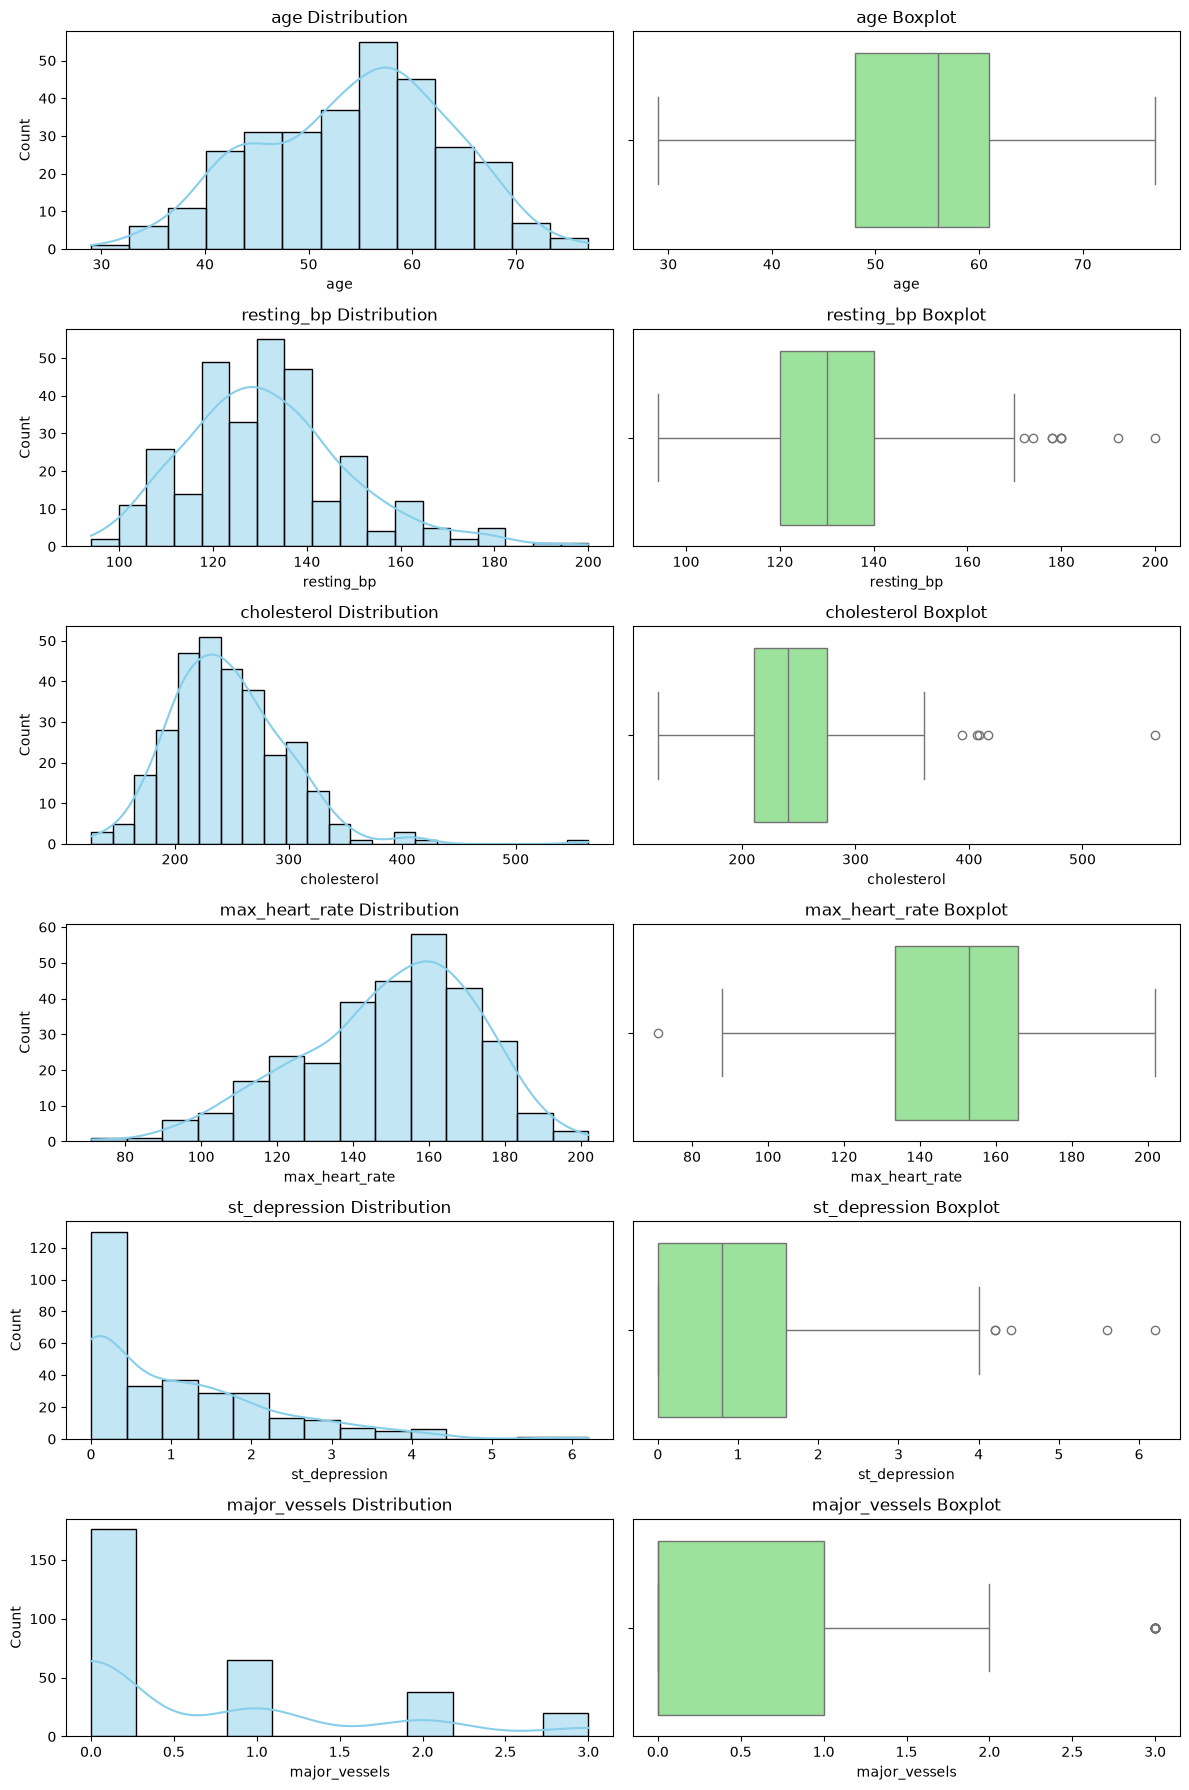

In [7]:
# Number of numerical columns
number_of_columns = len(numeric_features)
# Create rows and columns for graphs
fig, axes = plt.subplots(nrows=number_of_columns,ncols=2,figsize=(12, 3 * number_of_columns))

# Create graphs for each numerical column
for row, column in enumerate(numeric_features):
    sns.histplot(data=df,x=column,kde=True,ax=axes[row, 0],color="skyblue")
    axes[row, 0].set_title(column + " Distribution")
    sns.boxplot(data=df,x=column,ax=axes[row, 1],color="lightgreen")
    axes[row, 1].set_title(column + " Boxplot")
    
# Improve spacing between graphs
plt.tight_layout()
# Display all graphs
plt.show()

EDA

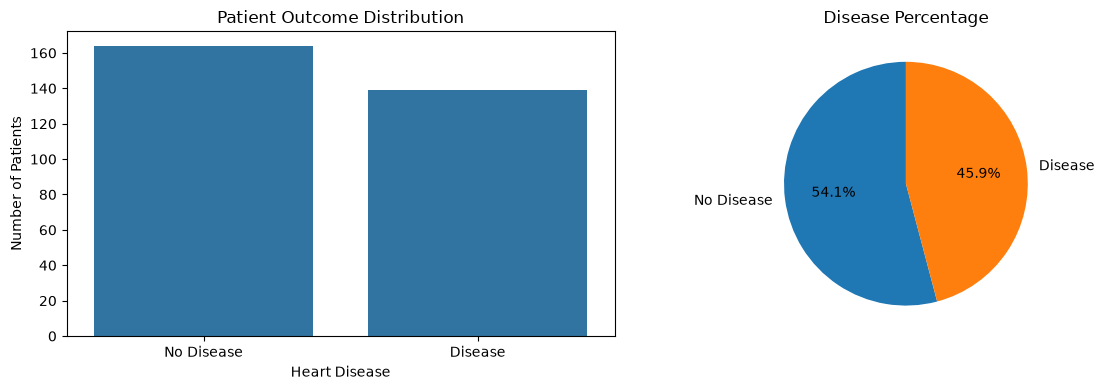

In [8]:
# Create one figure with two chart positions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df,x="heart_disease",ax=axes[0])
axes[0].set_title("Patient Outcome Distribution")
axes[0].set_xlabel("Heart Disease")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Disease", "Disease"])
# Calculate the number of patients
no_disease = (df["heart_disease"] == 0).sum()
disease = (df["heart_disease"] == 1).sum()

# Create the pie chart
axes[1].pie([no_disease, disease],labels=["No Disease", "Disease"],autopct="%1.1f%%",startangle=90)
axes[1].set_title("Disease Percentage")

plt.tight_layout() # Adjust spacing and display both charts
plt.show()

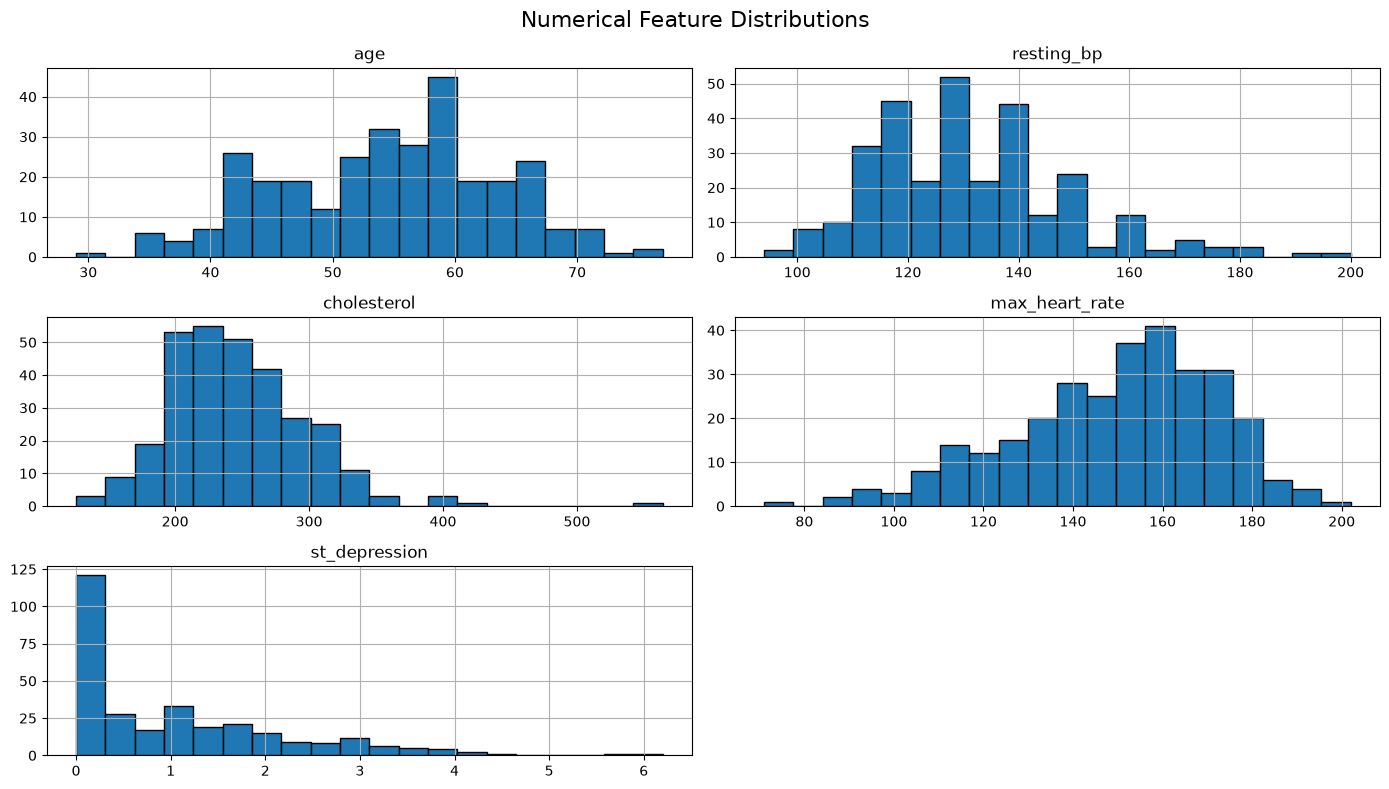

In [9]:
# Select numerical columns for visualization
plot_columns = ["age","resting_bp","cholesterol","max_heart_rate","st_depression"]
df[plot_columns].hist(figsize=(14, 8),bins=20,edgecolor="black")
plt.suptitle("Numerical Feature Distributions",fontsize=16)
plt.tight_layout()
plt.show()

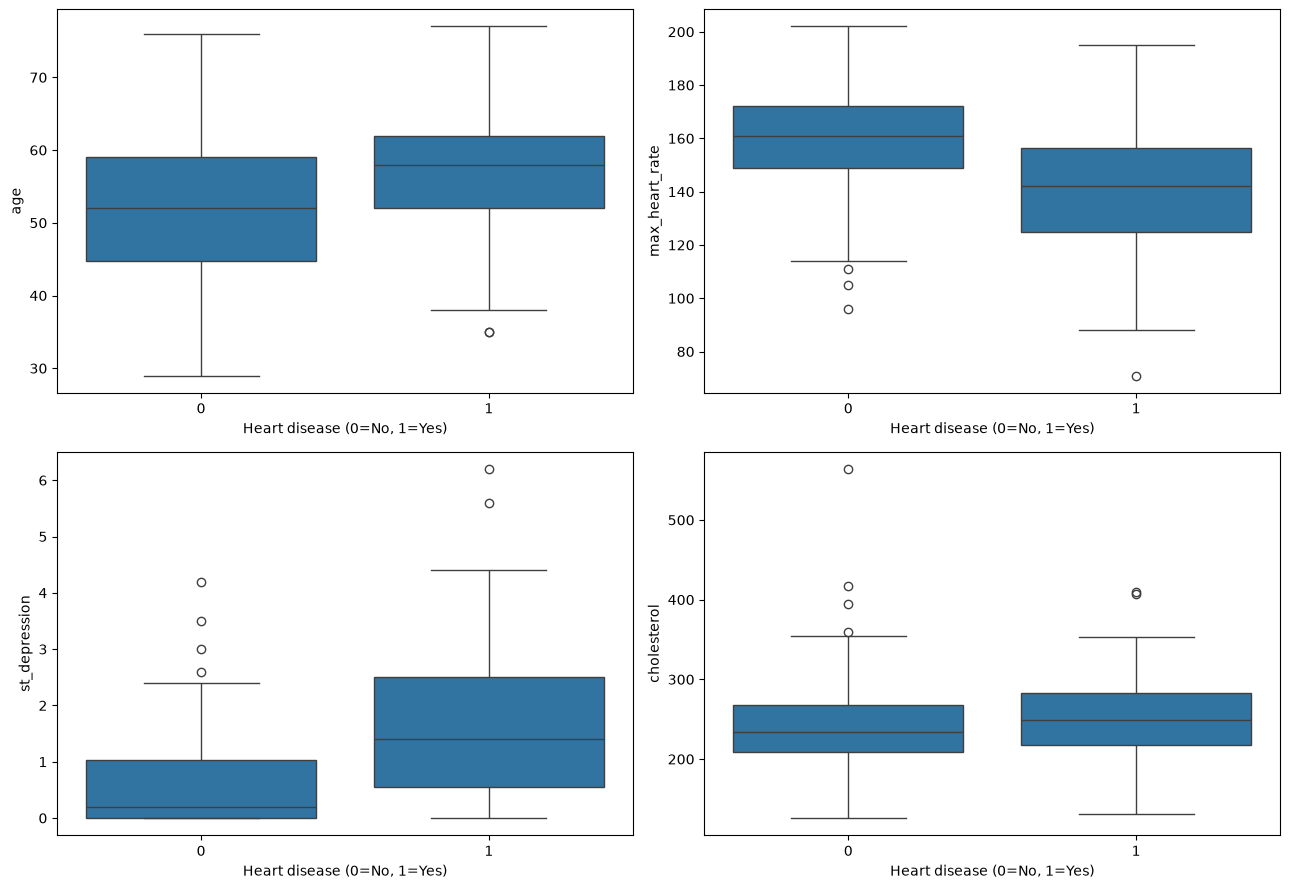

In [ ]:
# Data Distribution
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, ax in zip(["age", "max_heart_rate", "st_depression", "cholesterol"], axes.ravel()):
    sns.boxplot(data=df, x="heart_disease", y=col, ax=ax)
    ax.set_xlabel("Heart disease (0=No, 1=Yes)")
plt.tight_layout()
plt.show()

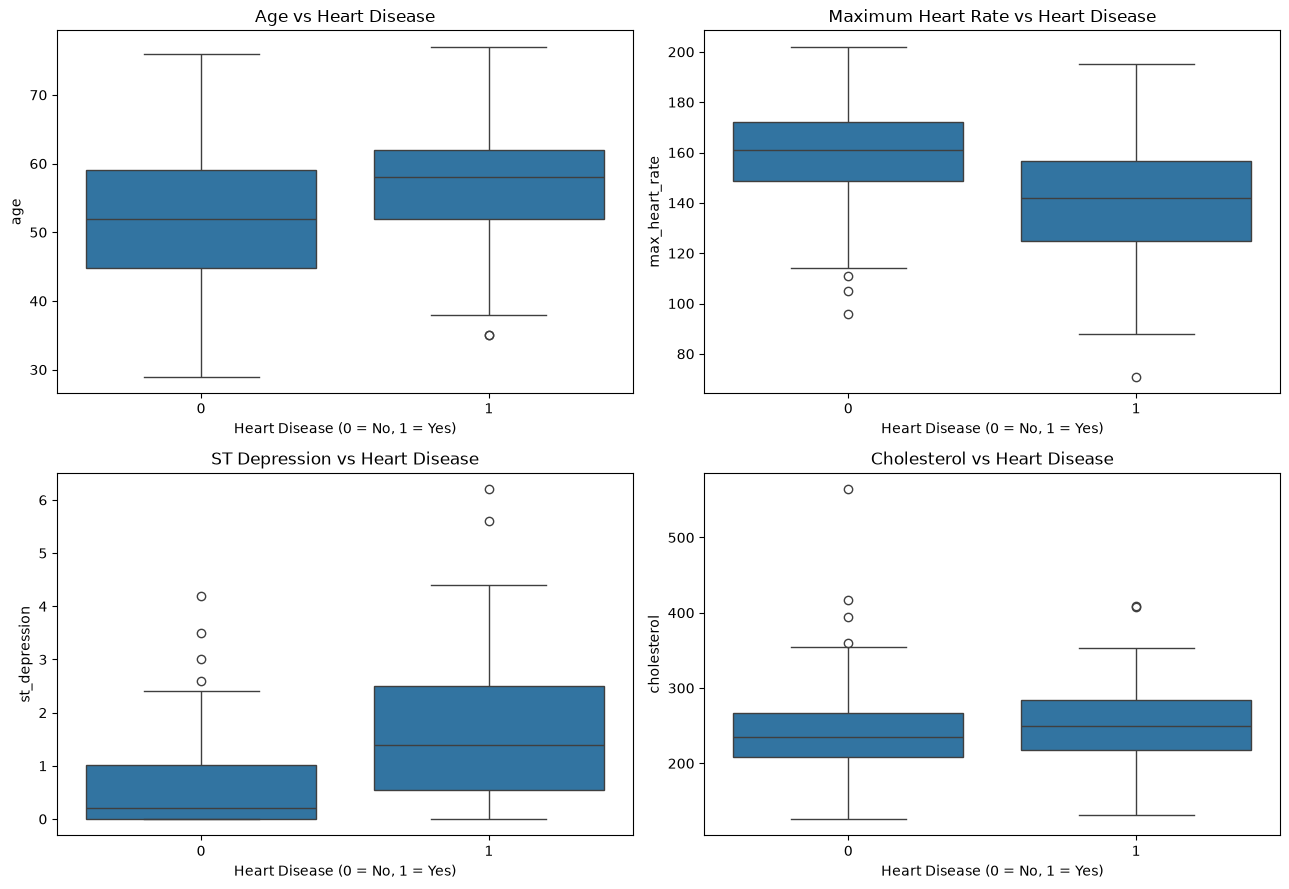

In [11]:
# Create chart heart disease vs Age, Maximum heart rate, ST depression, Cholesterol
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(data=df,x="heart_disease",y="age",ax=axes[0, 0])
axes[0, 0].set_title("Age vs Heart Disease")
axes[0, 0].set_xlabel("Heart Disease (0 = No, 1 = Yes)")
sns.boxplot(data=df,x="heart_disease",y="max_heart_rate",ax=axes[0, 1])
axes[0, 1].set_title("Maximum Heart Rate vs Heart Disease")
axes[0, 1].set_xlabel("Heart Disease (0 = No, 1 = Yes)")
sns.boxplot(data=df,x="heart_disease", y="st_depression", ax=axes[1, 0])
axes[1, 0].set_title("ST Depression vs Heart Disease")
axes[1, 0].set_xlabel("Heart Disease (0 = No, 1 = Yes)")
sns.boxplot(data=df,x="heart_disease",y="cholesterol",ax=axes[1, 1])
axes[1, 1].set_title("Cholesterol vs Heart Disease")
axes[1, 1].set_xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

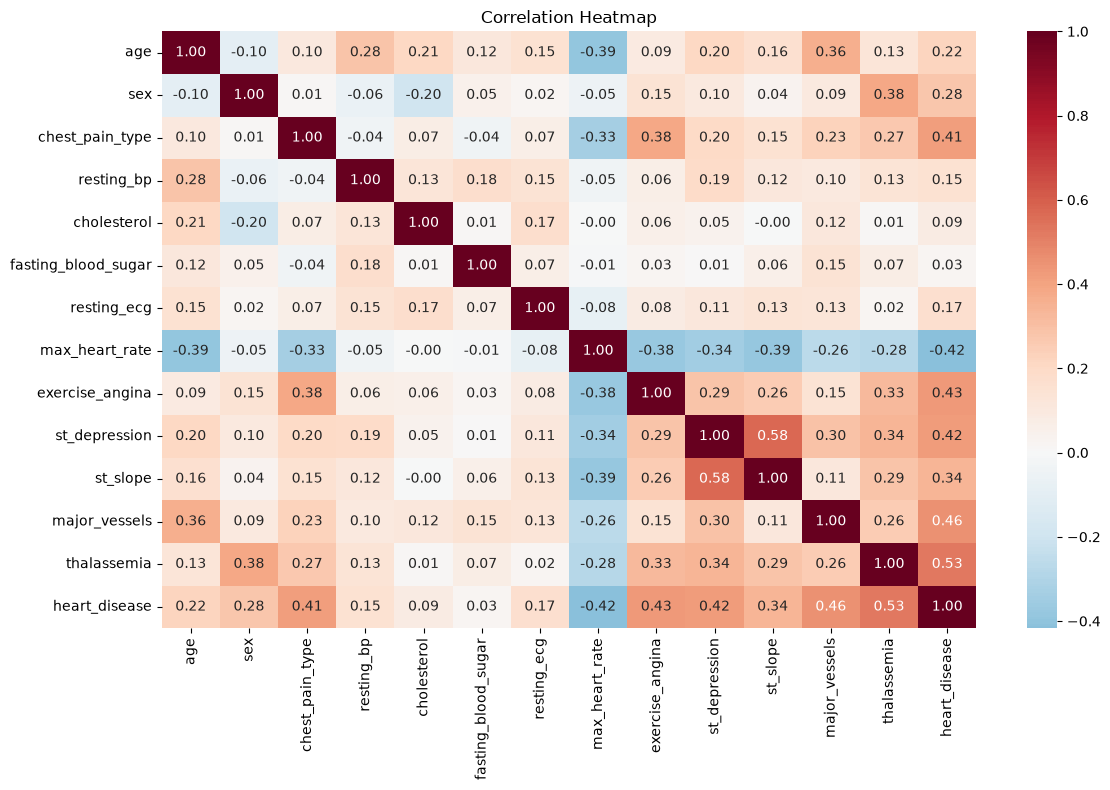

In [12]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Train/test split and leakage-safe preprocessing

In [13]:
#  Separate input features and target
X = df.drop(columns="heart_disease")
y = df["heart_disease"]

In [14]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

# Preprocess numerical columns
numeric_pipeline = Pipeline([
    # Fill missing values using the median
    ("fill_missing_values", SimpleImputer(strategy="median")),
    # Scale numerical values
    ("standard_scaling", StandardScaler())])

# Preprocess categorical columns
categorical_pipeline = Pipeline([
    # Fill missing values using the most common value
    ("fill_missing_values", SimpleImputer(strategy="most_frequent")),
    # Convert categories into numerical columns
    ("one_hot_encoding", OneHotEncoder(handle_unknown="ignore"))])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    ("numerical_columns", numeric_pipeline, numeric_features),
    ("categorical_columns", categorical_pipeline, categorical_features)])

# Check the number of rows
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 242
Testing rows: 61


Compare classification models with stratified cross-validation

In [15]:
# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Import model evaluation tools
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

# Create classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400,random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)}

# Create cross-validation
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Select evaluation metrics
scoring = ["accuracy","precision","recall","f1","roc_auc"]

# Create an empty list to store results
results = []
# Train and evaluate each model and Combine preprocessing and model
for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)])
    scores = cross_validate(pipeline,X_train,y_train,cv=cv,scoring=scoring)
    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean()})
    
# Convert results into a DataFrame
cv_results = pd.DataFrame(results)

# Arrange models from highest to lowest ROC-AUC
cv_results = cv_results.sort_values(by="ROC AUC",ascending=False).reset_index(drop=True)
display(cv_results.round(3))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.847,0.878,0.784,0.825,0.906
1,Random Forest,0.818,0.821,0.774,0.793,0.890
2,KNN,0.818,0.841,0.747,0.790,0.883
3,Gradient Boosting,0.798,0.784,0.775,0.777,0.854
4,Decision Tree,0.715,0.709,0.647,0.672,0.766


Fit the best cross-validated model and evaluate the unseen test set

In [16]:
# Import classification Evaluation metric
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay)
# Get the name of the best model
best_model_name = cv_results.iloc[0]["Model"]
print("Best model:", best_model_name)

# Get the best model from the models dictionary
selected_model = models[best_model_name]
# Combine preprocessing and the selected model
best_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", selected_model)])
# Train the model
best_model.fit(X_train, y_train)
# Predict patient outcomes
y_pred = best_model.predict(X_test)
# Predict disease probabilities
y_probability = best_model.predict_proba(X_test)[:, 1]

# Calculate model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

# Display individual results
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall/Sensitivity:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))

# Display the complete classification report
print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=["No disease", "Disease"]))

Best model: Logistic Regression
Accuracy: 0.869
Precision: 0.812
Recall/Sensitivity: 0.929
F1 Score: 0.867
ROC-AUC: 0.958

Classification Report:
              precision    recall  f1-score   support

  No disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



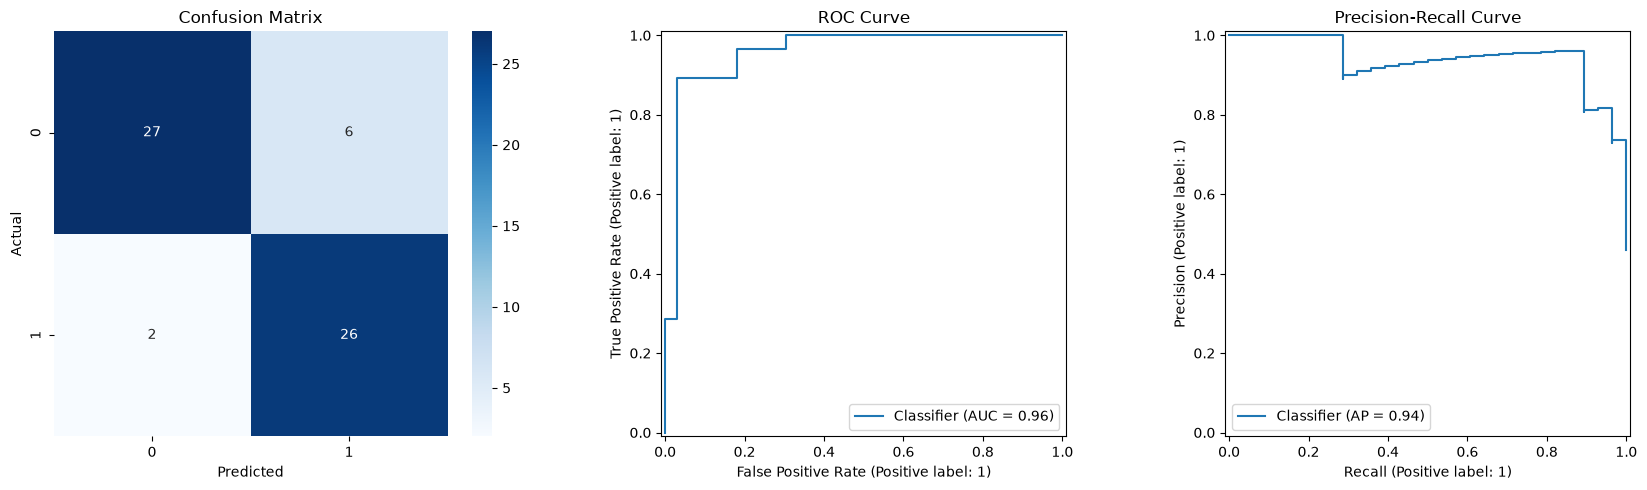

In [17]:
# Create three chart
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=ax[0])
ax[0].set_title("Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
# ROC Curve
RocCurveDisplay.from_predictions(y_test,y_probability,ax=ax[1])
ax[1].set_title("ROC Curve")
# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test,y_probability,ax=ax[2])
ax[2].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

Threshold analysis

,Threshold,Precision,Recall,F1 Score
0,0.20,0.683,1.000,0.812
1,0.25,0.737,1.000,0.848
2,0.30,0.730,0.964,0.831
3,0.35,0.750,0.964,0.844
4,0.40,0.794,0.964,0.871
5,0.45,0.818,0.964,0.885
6,0.50,0.812,0.929,0.867
7,0.55,0.806,0.893,0.847
8,0.60,0.893,0.893,0.893
9,0.65,0.893,0.893,0.893


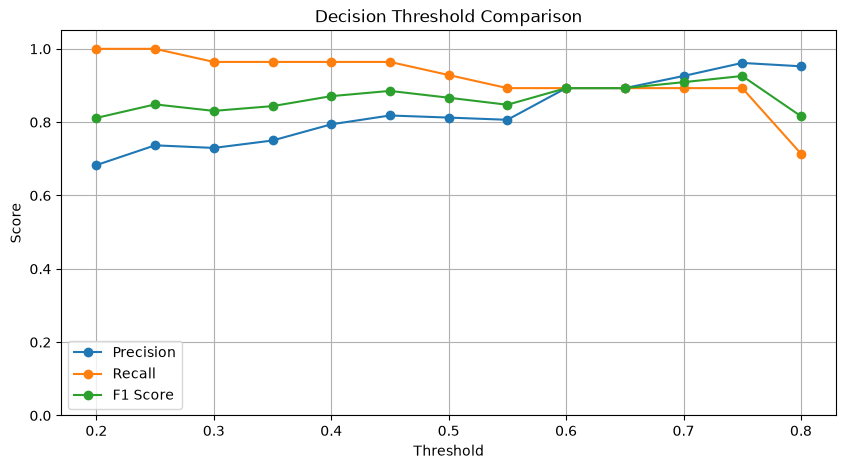

In [18]:
# Empty lists to store the results
thresholds = []
precision_scores = []
recall_scores = []
f1_scores = []
# Check thresholds from 0.20 to 0.80
for threshold in np.arange(0.20, 0.81, 0.05):
    # Convert probabilities into 0 or 1
    prediction = (y_probability >= threshold).astype(int)
    # Store threshold and metric results
    thresholds.append(threshold)
    precision_scores.append(precision_score(y_test, prediction, zero_division=0))
    recall_scores.append(recall_score(y_test, prediction, zero_division=0))
    f1_scores.append(f1_score(y_test, prediction, zero_division=0))

# Create a DataFrame
threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1 Score": f1_scores})

# Display the results
display(threshold_results.round(3))
# Create the line chart
plt.figure(figsize=(10, 5))
plt.plot(threshold_results["Threshold"],threshold_results["Precision"],marker="o",label="Precision")
plt.plot(threshold_results["Threshold"],threshold_results["Recall"],marker="o",label="Recall")
plt.plot(threshold_results["Threshold"],threshold_results["F1 Score"],marker="o",label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Decision Threshold Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

Model interpretation with permutation importance

,Feature,Importance
11,major_vessels,0.104
2,chest_pain_type,0.037
10,st_slope,0.015
8,exercise_angina,0.012
9,st_depression,0.012
12,thalassemia,0.011
7,max_heart_rate,0.010
1,sex,0.009
3,resting_bp,0.008
6,resting_ecg,0.005


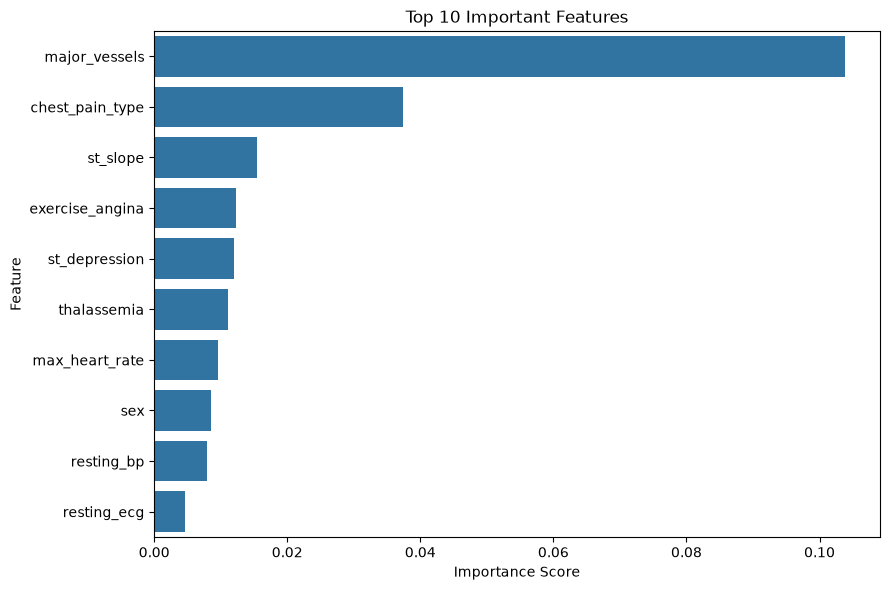

In [19]:
# Import permutation importance
from sklearn.inspection import permutation_importance
# 1. Calculate feature importance
importance_result = permutation_importance(best_model,X_test,y_test,scoring="roc_auc",n_repeats=10,random_state=42)
# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_result.importances_mean})

# Sort features from most important to least important
importance_df = importance_df.sort_values(by="Importance",ascending=False)
# Display feature importance
display(importance_df.round(3))
# Select the 10 most important features
top_10_features = importance_df.head(10)
# Create a bar chart
plt.figure(figsize=(9, 6))
sns.barplot(data=top_10_features,x="Importance",y="Feature")
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Save reproducible outputs

In [20]:
import joblib
joblib.dump(best_model, "heart_disease_model.joblib")
cv_results.to_csv("model_comparison.csv", index=False)
importance_df.to_csv("feature_importance.csv", index=False)
print("Saved model and result tables.")

Saved model and result tables.


Conclusions and limitations

- Select the final model using cross-validated ROC-AUC together with recall and F1-score.
- Use the held-out test set only once for the final performance estimate.
- Report the confusion matrix because the two error types have different practical consequences.
- Feature importance shows association with predictions, not causation.
- The Cleveland sample is small and historical; performance may not generalize across hospitals, countries, demographic groups, or modern care settings.
- Before any real clinical use, the model would require external validation, calibration checks, fairness analysis, clinical governance, privacy controls, and prospective evaluation.